
# Contents
### 1. The Iris CubeList and Cube objects
### 2. Plotting with iris
#### 2.1 Regional example
#### 2.2 Global example
---

# 1. The Iris CubeList and Cube objects

- NetCDF file provided contains air temperature and vertical velocity diagnostics on the hour for a 10-hour LFRic CRM simulation
- The dataset has coordinates (time, z, y, x) with shape (10, 141, 128, 128)

In [1]:
import warnings
import iris
warnings.filterwarnings("ignore",module="iris.coords")
iris.FUTURE.date_microseconds = True

# Load the dataset
cubes = iris.load('crm_cbl.nc')

# If multiple diagnostics are present in the file, iris.load() will return a CubeList object containing multiple Cube objects.
# Each cube represents a different diagnostic and has its own metadata and data array.

In [2]:
# Check if the cubes have lazy data (i.e., data that has not been loaded into memory yet)
for cube in cubes:
    print(f"Cube '{cube.name()}' has lazy data: {cube.has_lazy_data()}")

Cube 'air_temperature' has lazy data: True
Cube 'upward_air_velocity' has lazy data: True


In [3]:
cubes

[<iris 'Cube' of air_temperature / (K) (time: 10; height: 141; y: 128; x: 128)>,
<iris 'Cube' of upward_air_velocity / (m s-1) (time: 10; height: 141; y: 128; x: 128)>]

In [4]:
cubes[0]

<iris 'Cube' of air_temperature / (K) (time: 10; height: 141; y: 128; x: 128)>

In [5]:
# Print the coordinates
cubes[0].coords()

[<DimCoord: time / (seconds since 2007-07-15 10:00:00)  [...]+bounds  shape(10,)>,
 <DimCoord: height / (km)  [0.000e+00, 2.000e-03, ..., 3.706e+01, 4.000e+01]  shape(141,)>,
 <DimCoord: y / (km)  [0. , 0.035, ..., 4.41 , 4.445]+bounds  shape(128,)>,
 <DimCoord: x / (km)  [0. , 0.035, ..., 4.41 , 4.445]+bounds  shape(128,)>,
 <AuxCoord: full_levels / (unknown)  [ 0., 1., ..., 139., 140.]  shape(141,)>]

# 2. Plotting with iris 

## 2.1 Regional example

In [6]:
import iris.quickplot as qplt
# The iris quickplot module allows for quick visualisation of data in an iris cube

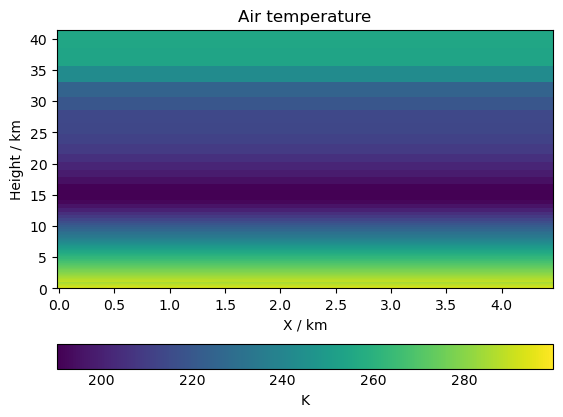

In [7]:
# air_temperature example
air_temp_cube = cubes.extract('air_temperature')[0] # Extract the first (and only, in this case) cube with standard_name 'air_temperature'
upward_air_velocity_cube = cubes.extract('upward_air_velocity')[0] # Extract upward_air_velocity cube

qplt.pcolormesh(air_temp_cube[0, :, 64, :])  # Plot the first time step

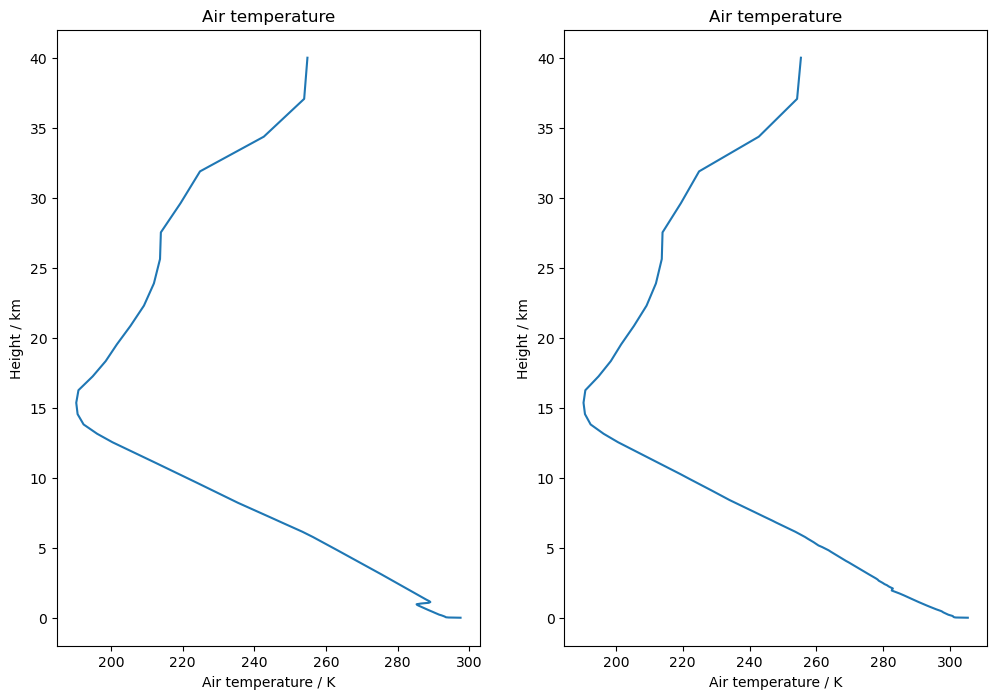

In [8]:
# Plot the initial and final states for the central column of the domain

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Initial 
plt.subplot(1, 2, 1)
qplt.plot(air_temp_cube[0, :, 64, 64],air_temp_cube[0, :, 64, 64].coord("height")) # Plot the first time step
ax = plt.gca()

# Final
ax = plt.subplot(1, 2, 2)
qplt.plot(air_temp_cube[-1, :, 64, 64],air_temp_cube[-1, :, 64, 64].coord("height")) # Plot the last time step

plt.show()

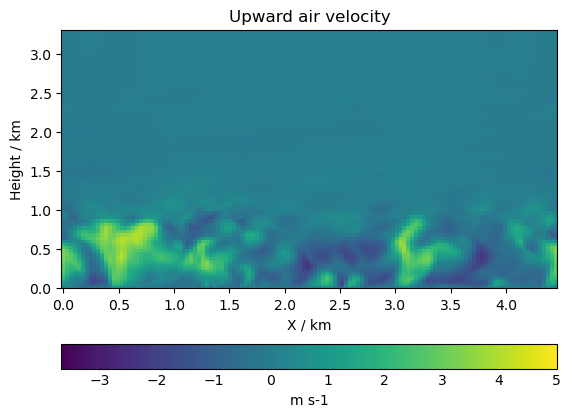

In [9]:
# Animation example

import iris.plot as iplt
import cartopy.crs as ccrs

# Ensure inline animation rendering in Jupyter
plt.rcParams['animation.html'] = 'html5'
from IPython.display import HTML

cube_iter = upward_air_velocity_cube[:,0:70,64,:].slices_over('time')

ani = iplt.animate(cube_iter, qplt.pcolormesh)
# Display inline in notebook
HTML(ani.to_jshtml(fps=5))

## 3.2 Global example

In [10]:
fname = iris.sample_data_path('air_temp.pp') # Load sample dataset
cubes = iris.load(fname) 
cube = cubes[0] # Extract the first cube (air temperature)
cube

<iris 'Cube' of air_temperature / (K) (latitude: 73; longitude: 96)>

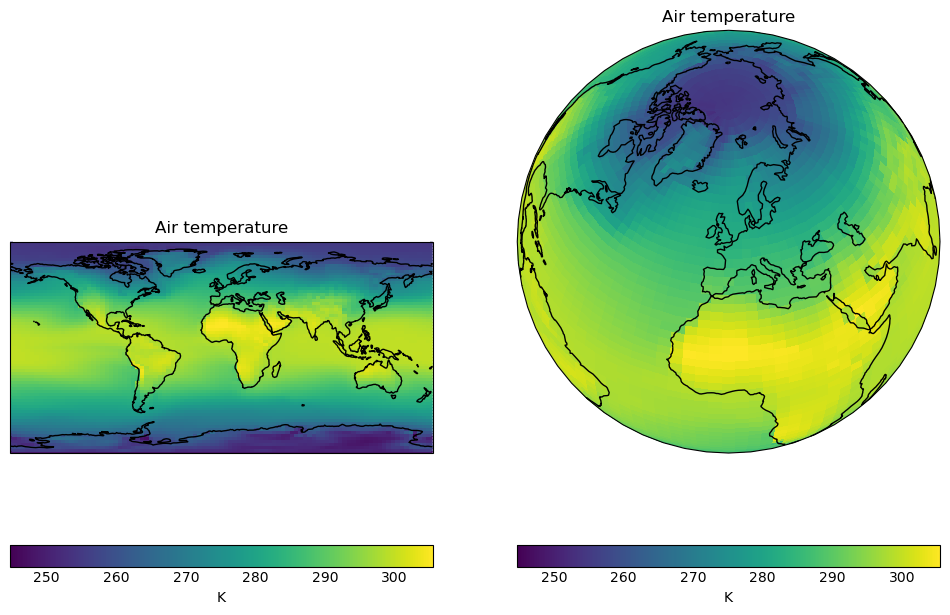

In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
qplt.pcolormesh(cube)
ax = plt.gca()
ax.coastlines() # Add coastlines to the plot

ax = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=0, central_latitude=51)) # Create a subplot with an orthographic projection centered on UK
qplt.pcolormesh(cube)
ax.coastlines()

plt.show()